# Capstone Project 2 – Technical Notebook
## Predicting Mobile Phone Theft Risk in London Using Historical Crime Data

**Programme:** PGA 3.0  |  **Track:** Specialisation Track 2 (Machine Learning)  
**Focus:** Classification of London boroughs & time periods into **Low / Medium / High** mobile-phone-theft risk.

This notebook contains the **complete technical pipeline**:
1. Data Loading & Filtering  
2. Data Cleaning  
3. Risk Label Creation  
4. Feature Engineering / Data Transformation  
5. Exploratory Data Analysis (EDA) & Visualisation  
6. Model Data Preparation  
7. Model Building & Evaluation  
8. Model Tuning (Hyperparameter Optimisation)  
9. Model Persistence (Deployment-ready artefacts)  
10. Business Insights & Recommendations

---
**Data source:** Metropolitan Police / London DataStore – Monthly Crime Dashboard (Other Crime Data)  
**Filtered subtypes:** `Theft Person - Mobile phone` + `Robbery Mobile phone`

## 0. Imports & Setup

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score)
from sklearn.pipeline import Pipeline
import joblib

try:
    from xgboost import XGBClassifier
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    print('XGBoost not available – will skip that model.')

# Paths (adjust if running elsewhere)
# Paths (macOS local)
BASE = Path.home() / 'phone_theft_project'   # e.g. /Users/kevin/phone_theft_project
DATA_DIR = BASE / 'data'
FIG_DIR  = BASE / 'figures'
MODEL_DIR = BASE / 'models'
for d in [DATA_DIR, FIG_DIR, MODEL_DIR]:
    d.mkdir(parents=True, exist_ok=True)

RAW_CSV = '/Users/kevindobariya/Downloads/M1045_MonthlyCrimeDashboard_OtherCrimeData.csv'
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', 50)
print('Setup complete.')

Setup complete.


## 1. Data Loading and Filtering

We load the full monthly crime dashboard and keep only the two mobile-phone-related subtypes, then restrict to **Borough-level Offences**.

In [6]:
df_raw = pd.read_csv(RAW_CSV)
print(f'Raw rows: {len(df_raw):,}')

# Filter phone-theft related records
phone_mask = df_raw['Crime Subtype'].isin(
    ['Theft Person - Mobile phone', 'Robbery Mobile phone']
)
phone = df_raw[phone_mask].copy()
print(f'Phone-related rows: {len(phone):,}')
print(phone['Crime Subtype'].value_counts())

# Borough level + Offences only
borough = phone[
    (phone['Area Type'] == 'Borough') &
    (phone['Measure'] == 'Offences')
].copy()
print(f'\nBorough-level Offences rows: {len(borough):,}')

# Aggregate both subtypes into a single monthly count per borough
agg = (
    borough.groupby(['Month_Year', 'Borough_SNT', 'Area Code'])['Count']
    .sum()
    .reset_index()
    .rename(columns={'Borough_SNT': 'Borough', 'Count': 'Theft_Count'})
)
agg['Month_Year'] = pd.to_datetime(agg['Month_Year'])
agg = agg.sort_values(['Borough', 'Month_Year']).reset_index(drop=True)

print(f'\nAggregated borough-month rows: {len(agg):,}')
print(f'Date range: {agg["Month_Year"].min().date()} → {agg["Month_Year"].max().date()}')
print(f'Boroughs: {agg["Borough"].nunique()}')
print(f'Total thefts: {agg["Theft_Count"].sum():,}')

agg.to_csv(DATA_DIR / 'phone_theft_borough_monthly.csv', index=False)
agg.head(10)

Raw rows: 428,050
Phone-related rows: 43,338
Crime Subtype
Theft Person - Mobile phone    23643
Robbery Mobile phone           19695
Name: count, dtype: int64

Borough-level Offences rows: 3,071

Aggregated borough-month rows: 1,536
Date range: 2022-06-01 → 2026-05-01
Boroughs: 32
Total thefts: 269,903


,Month_Year,Borough,Area Code,Theft_Count
0,2022-06-01,Barking and Dagenham,E09000002,34
1,2022-07-01,Barking and Dagenham,E09000002,27
2,2022-08-01,Barking and Dagenham,E09000002,16
3,2022-09-01,Barking and Dagenham,E09000002,17
4,2022-10-01,Barking and Dagenham,E09000002,47
5,2022-11-01,Barking and Dagenham,E09000002,64
6,2022-12-01,Barking and Dagenham,E09000002,70
7,2023-01-01,Barking and Dagenham,E09000002,59
8,2023-02-01,Barking and Dagenham,E09000002,59
9,2023-03-01,Barking and Dagenham,E09000002,53


## 2. Data Cleaning

Check missing values, duplicates, and basic distribution. The extracted panel is already clean.

In [7]:
print('Missing values:')
print(agg.isnull().sum())
print(f'\nDuplicates: {agg.duplicated().sum()}')
print(f'Min count: {agg["Theft_Count"].min()}, Max: {agg["Theft_Count"].max()}')
print(f'Zero counts: {(agg["Theft_Count"] == 0).sum()}')

df = agg.copy()
df['Theft_Count'] = df['Theft_Count'].astype(int)
df['Year']  = df['Month_Year'].dt.year
df['Month'] = df['Month_Year'].dt.month
df['YearMonth'] = df['Month_Year'].dt.to_period('M').astype(str)

print('\nData is clean – no imputation required.')
df.describe()

Missing values:
Month_Year     0
Borough        0
Area Code      0
Theft_Count    0
dtype: int64

Duplicates: 0
Min count: 3, Max: 3466
Zero counts: 0

Data is clean – no imputation required.


,Month_Year,Theft_Count,Year,Month
count,1536,1536.000000,1536.000000,1536.000000
mean,2024-05-16 15:30:00,175.718099,2023.916667,6.500000
min,2022-06-01 00:00:00,3.000000,2022.000000,1.000000
25%,2023-05-24 06:00:00,38.000000,2023.000000,3.750000
50%,2024-05-16 12:00:00,72.000000,2024.000000,6.500000
75%,2025-05-08 18:00:00,187.500000,2025.000000,9.250000
max,2026-05-01 00:00:00,3466.000000,2026.000000,12.000000
std,NaN,326.224685,1.222304,3.453177


## 3. Risk Label Creation

We create the target variable **Risk** (Low / Medium / High) using tertiles of `Theft_Count` so that classes are approximately balanced and operationally meaningful.

In [8]:
q33 = df['Theft_Count'].quantile(0.33)
q66 = df['Theft_Count'].quantile(0.66)
print(f'Tertile thresholds → Low ≤ {q33:.0f} | Medium ≤ {q66:.0f} | High > {q66:.0f}')

def risk_label(x):
    if x <= q33:
        return 'Low'
    elif x <= q66:
        return 'Medium'
    else:
        return 'High'

df['Risk'] = df['Theft_Count'].apply(risk_label)
risk_map = {'Low': 0, 'Medium': 1, 'High': 2}
df['Risk_Num'] = df['Risk'].map(risk_map)

print('\nClass distribution:')
print(df['Risk'].value_counts().sort_index())
df[['Borough', 'Month_Year', 'Theft_Count', 'Risk']].sample(8, random_state=42)

Tertile thresholds → Low ≤ 50 | Medium ≤ 118 | High > 118

Class distribution:
Risk
High      518
Low       513
Medium    505
Name: count, dtype: int64


,Borough,Month_Year,Theft_Count,Risk
1159,Redbridge,2023-01-01,78,Medium
76,Barnet,2024-10-01,62,Medium
316,Croydon,2024-10-01,58,Medium
1040,Lewisham,2025-02-01,68,Medium
1357,Tower Hamlets,2023-07-01,170,High
924,Kingston upon Thames,2023-06-01,23,Low
757,Hillingdon,2025-07-01,80,Medium
1505,Westminster,2023-11-01,2800,High


## 4. Feature Engineering / Data Transformation

Create lag features, rolling means, cyclical month encoding, and a borough-level context feature. Early months that lack full lag history are dropped.

In [9]:
df = df.sort_values(['Borough', 'Month_Year'])

# Lags
df['Lag1_Count'] = df.groupby('Borough')['Theft_Count'].shift(1)
df['Lag2_Count'] = df.groupby('Borough')['Theft_Count'].shift(2)
df['Lag3_Count'] = df.groupby('Borough')['Theft_Count'].shift(3)

# Rolling means (past only)
df['Roll3_Mean'] = df.groupby('Borough')['Theft_Count'].transform(
    lambda x: x.shift(1).rolling(3, min_periods=1).mean())
df['Roll6_Mean'] = df.groupby('Borough')['Theft_Count'].transform(
    lambda x: x.shift(1).rolling(6, min_periods=1).mean())

# Cyclical month encoding
df['Month_Sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_Cos'] = np.cos(2 * np.pi * df['Month'] / 12)

# Relative year & borough long-run mean
df['Year_Rel'] = df['Year'] - df['Year'].min()
borough_means = df.groupby('Borough')['Theft_Count'].mean().to_dict()
df['Borough_Mean_Theft'] = df['Borough'].map(borough_means)

# Drop rows missing lag history
df_model = df.dropna(subset=['Lag1_Count', 'Lag2_Count', 'Lag3_Count']).copy()
print(f'Rows after lag features: {len(df_model):,}')
print('Features ready: Lag1/2/3_Count, Roll3/6_Mean, Month_Sin/Cos, Year_Rel, Borough_Mean_Theft')
df_model.head()

Rows after lag features: 1,440
Features ready: Lag1/2/3_Count, Roll3/6_Mean, Month_Sin/Cos, Year_Rel, Borough_Mean_Theft


,Month_Year,Borough,Area Code,Theft_Count,Year,Month,YearMonth,Risk,Risk_Num,Lag1_Count,Lag2_Count,Lag3_Count,Roll3_Mean,Roll6_Mean,Month_Sin,Month_Cos,Year_Rel,Borough_Mean_Theft
3,2022-09-01,Barking and Dagenham,E09000002,17,2022,9,2022-09,Low,0,16.0,27.0,34.0,25.666667,25.666667,-1.000000e+00,-1.836970e-16,0,59.979167
4,2022-10-01,Barking and Dagenham,E09000002,47,2022,10,2022-10,Low,0,17.0,16.0,27.0,20.000000,23.500000,-8.660254e-01,5.000000e-01,0,59.979167
5,2022-11-01,Barking and Dagenham,E09000002,64,2022,11,2022-11,Medium,1,47.0,17.0,16.0,26.666667,28.200000,-5.000000e-01,8.660254e-01,0,59.979167
6,2022-12-01,Barking and Dagenham,E09000002,70,2022,12,2022-12,Medium,1,64.0,47.0,17.0,42.666667,34.166667,-2.449294e-16,1.000000e+00,0,59.979167
7,2023-01-01,Barking and Dagenham,E09000002,59,2023,1,2023-01,Medium,1,70.0,64.0,47.0,60.333333,40.166667,5.000000e-01,8.660254e-01,1,59.979167


## 5. Exploratory Data Analysis (EDA) & Visualisation

Key visualisations are saved to the `figures/` folder and also displayed inline.

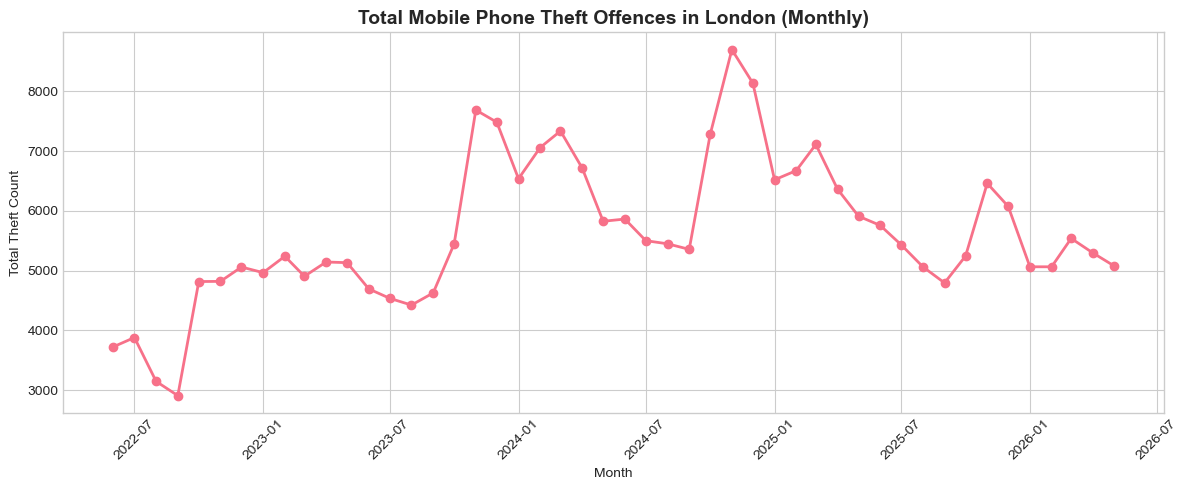

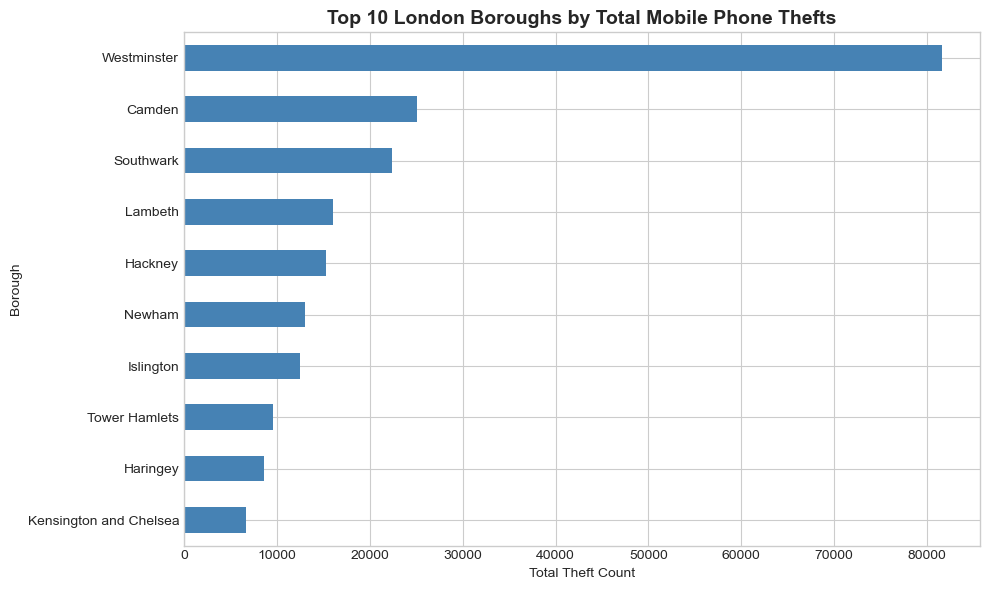

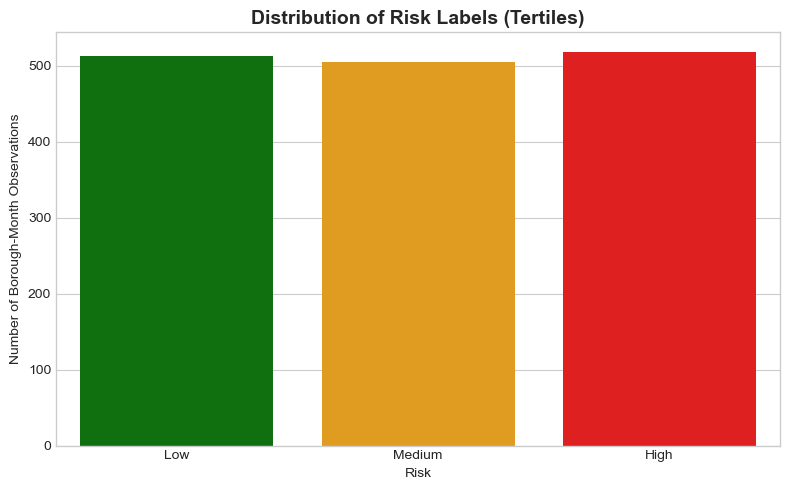

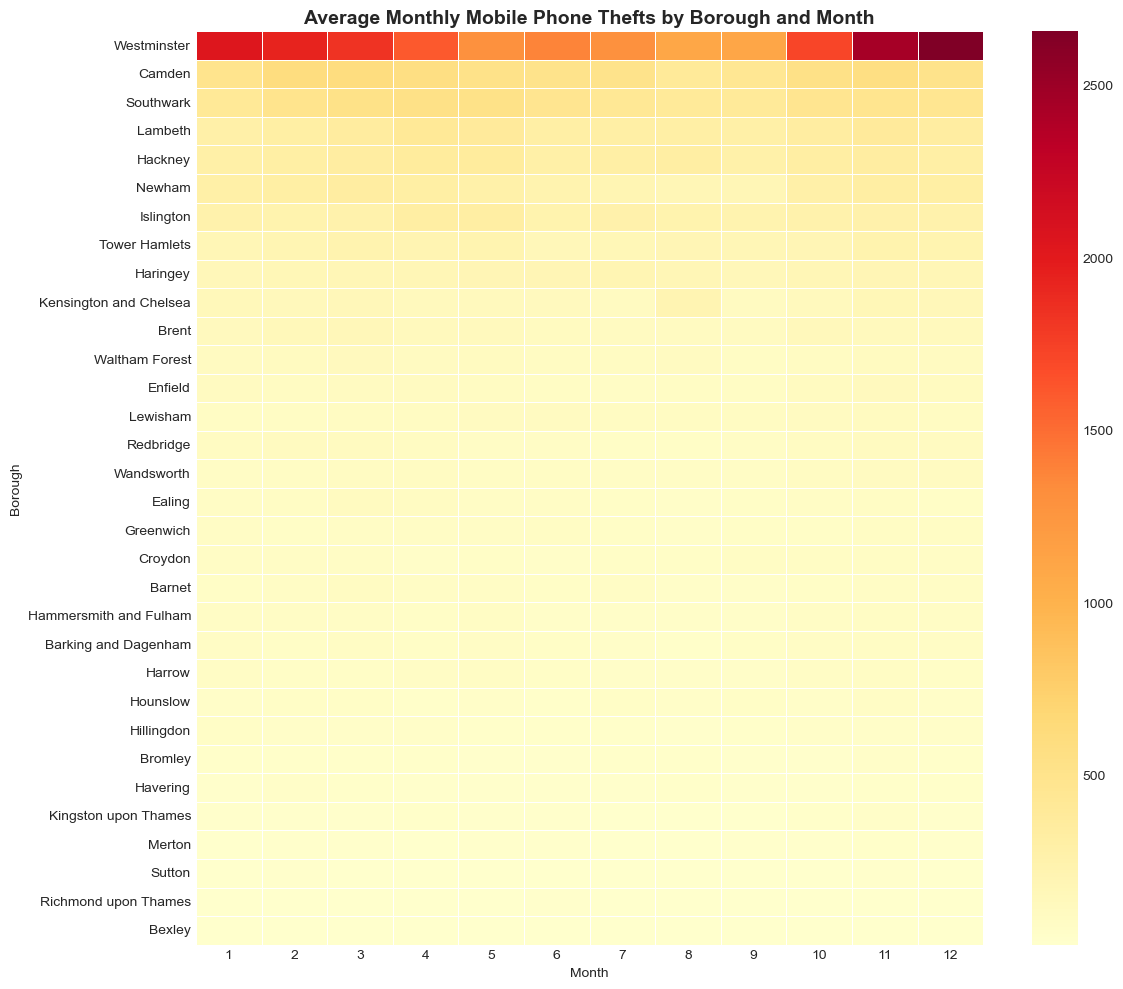

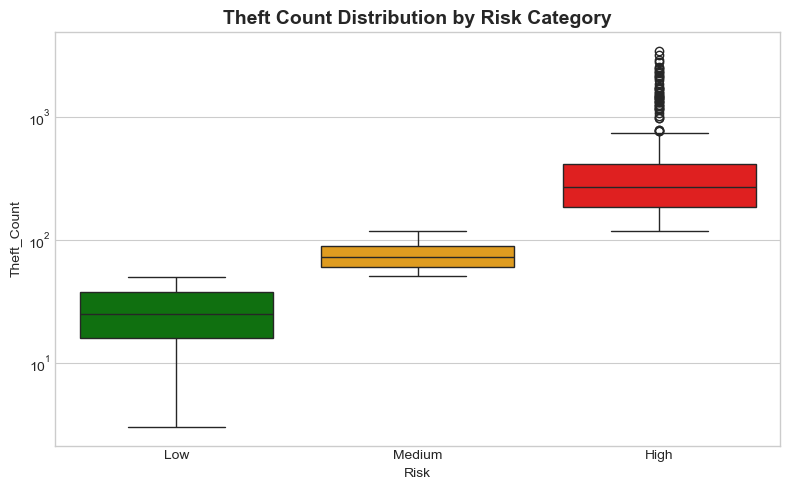

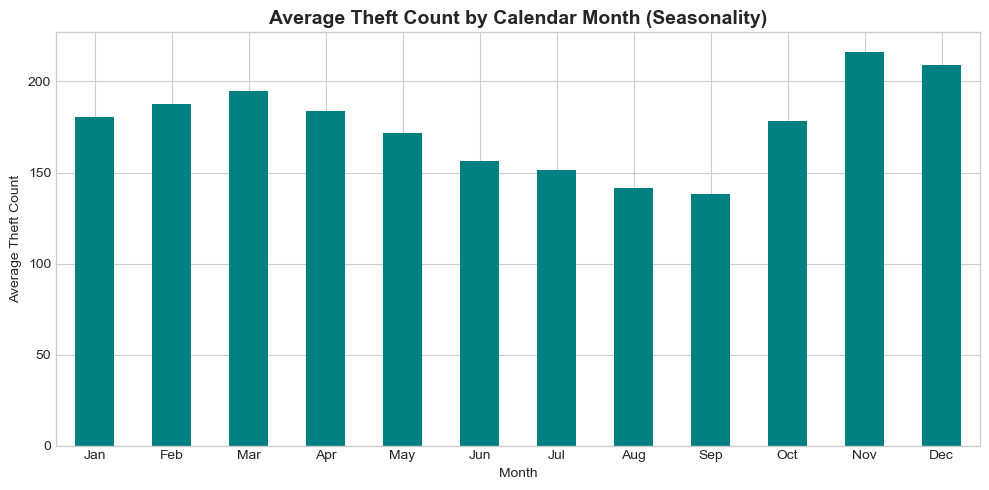

All EDA figures saved to /Users/kevindobariya/phone_theft_project/figures


In [10]:
# 5.1 Overall monthly trend
monthly_total = df.groupby('Month_Year')['Theft_Count'].sum().reset_index()
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(monthly_total['Month_Year'], monthly_total['Theft_Count'], marker='o', linewidth=2)
ax.set_title('Total Mobile Phone Theft Offences in London (Monthly)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Theft Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(FIG_DIR / '01_monthly_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# 5.2 Top 10 boroughs
top_boroughs = df.groupby('Borough')['Theft_Count'].sum().sort_values(ascending=False).head(10)
fig, ax = plt.subplots(figsize=(10, 6))
top_boroughs.plot(kind='barh', ax=ax, color='steelblue')
ax.set_title('Top 10 London Boroughs by Total Mobile Phone Thefts', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Theft Count')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(FIG_DIR / '02_top_boroughs.png', dpi=150, bbox_inches='tight')
plt.show()

# 5.3 Risk distribution
fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(data=df, x='Risk', order=['Low', 'Medium', 'High'], ax=ax,
              palette=['green', 'orange', 'red'])
ax.set_title('Distribution of Risk Labels (Tertiles)', fontsize=14, fontweight='bold')
ax.set_ylabel('Number of Borough-Month Observations')
plt.tight_layout()
plt.savefig(FIG_DIR / '03_risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# 5.4 Heatmap – average thefts by Borough × Month
pivot = df.pivot_table(values='Theft_Count', index='Borough', columns='Month', aggfunc='mean')
order = df.groupby('Borough')['Theft_Count'].sum().sort_values(ascending=False).index
pivot = pivot.reindex(order)
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(pivot, cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Average Monthly Mobile Phone Thefts by Borough and Month', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / '04_borough_month_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# 5.5 Boxplot by risk
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df, x='Risk', y='Theft_Count', order=['Low', 'Medium', 'High'],
            ax=ax, palette=['green', 'orange', 'red'])
ax.set_title('Theft Count Distribution by Risk Category', fontsize=14, fontweight='bold')
ax.set_yscale('log')
plt.tight_layout()
plt.savefig(FIG_DIR / '05_boxplot_risk.png', dpi=150, bbox_inches='tight')
plt.show()

# 5.6 Seasonality
monthly_avg = df.groupby('Month')['Theft_Count'].mean()
fig, ax = plt.subplots(figsize=(10, 5))
monthly_avg.plot(kind='bar', ax=ax, color='teal')
ax.set_title('Average Theft Count by Calendar Month (Seasonality)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Average Theft Count')
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'], rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / '06_seasonality.png', dpi=150, bbox_inches='tight')
plt.show()

print('All EDA figures saved to', FIG_DIR)

### Quick EDA Insights
- **Westminster** accounts for a disproportionately large share of recorded mobile-phone thefts.
- Risk is highly **persistent** across months for the same borough (strong lag signal).
- Clear **seasonal** variation is visible.
- Tertile labels produce well-separated and roughly balanced classes.

## 6. Model Data Preparation

In [11]:
feature_cols = [
    'Lag1_Count', 'Lag2_Count', 'Lag3_Count',
    'Roll3_Mean', 'Roll6_Mean',
    'Month_Sin', 'Month_Cos', 'Year_Rel', 'Borough_Mean_Theft'
]

X = df_model[feature_cols].copy()
y = df_model['Risk']

le = LabelEncoder()
y_enc = le.fit_transform(y)

print('Feature matrix shape:', X.shape)
print('Classes:', le.classes_)
print('\nClass distribution:')
print(pd.Series(y).value_counts())

X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.25, random_state=42, stratify=y_enc
)
print(f'\nTrain size: {len(X_train)} | Test size: {len(X_test)}')

Feature matrix shape: (1440, 9)
Classes: ['High' 'Low' 'Medium']

Class distribution:
Risk
High      495
Medium    480
Low       465
Name: count, dtype: int64

Train size: 1080 | Test size: 360


## 7. Model Building and Evaluation

We train several classifiers and compare them on accuracy and weighted F1.


--- Logistic Regression ---
Accuracy: 0.8778 | Weighted F1: 0.8786
              precision    recall  f1-score   support

        High       0.93      0.92      0.92       124
         Low       0.92      0.86      0.89       116
      Medium       0.80      0.85      0.82       120

    accuracy                           0.88       360
   macro avg       0.88      0.88      0.88       360
weighted avg       0.88      0.88      0.88       360


--- Random Forest ---
Accuracy: 0.8750 | Weighted F1: 0.8760
              precision    recall  f1-score   support

        High       0.92      0.93      0.92       124
         Low       0.94      0.83      0.88       116
      Medium       0.78      0.87      0.82       120

    accuracy                           0.88       360
   macro avg       0.88      0.87      0.88       360
weighted avg       0.88      0.88      0.88       360


--- Gradient Boosting ---
Accuracy: 0.8611 | Weighted F1: 0.8620
              precision    recall  f1-scor

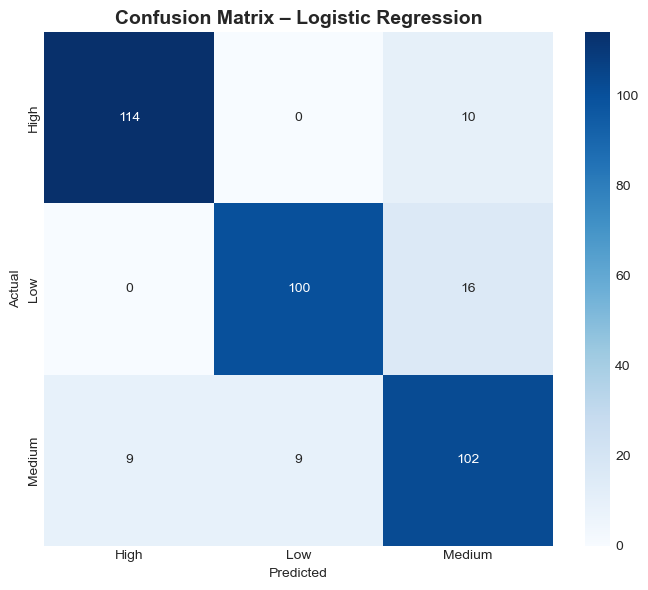

In [12]:
models = {
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42))
    ]),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
}
if HAS_XGB:
    models['XGBoost'] = XGBClassifier(random_state=42, eval_metric='mlogloss', n_jobs=-1)

results = {}
best_model = None
best_score = -1
best_name = None

for name, model in models.items():
    print(f'\n--- {name} ---')
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1  = f1_score(y_test, y_pred, average='weighted')
    print(f'Accuracy: {acc:.4f} | Weighted F1: {f1:.4f}')
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    results[name] = {'accuracy': acc, 'f1': f1, 'model': model, 'y_pred': y_pred}
    if f1 > best_score:
        best_score = f1
        best_model = model
        best_name = name

print(f'\nBest base model: {best_name} (Weighted F1 = {best_score:.4f})')

# Confusion matrix for best base model
cm = confusion_matrix(y_test, results[best_name]['y_pred'])
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f'Confusion Matrix – {best_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(FIG_DIR / '07_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Model Tuning (Hyperparameter Optimisation)

We perform GridSearchCV on Random Forest and Gradient Boosting and select the strongest final model.

In [13]:
print('Tuning Random Forest...')
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [8, 12, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
grid_rf = GridSearchCV(rf, param_grid_rf, cv=StratifiedKFold(3),
                       scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_rf.fit(X_train, y_train)
print('Best RF params:', grid_rf.best_params_)
print(f'Best CV F1: {grid_rf.best_score_:.4f}')

y_pred_rf = grid_rf.predict(X_test)
rf_f1 = f1_score(y_test, y_pred_rf, average='weighted')
print(f'Test Weighted F1 (tuned RF): {rf_f1:.4f}')
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

print('\nTuning Gradient Boosting...')
param_grid_gb = {
    'n_estimators': [100, 150],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 5]
}
gb = GradientBoostingClassifier(random_state=42)
grid_gb = GridSearchCV(gb, param_grid_gb, cv=StratifiedKFold(3),
                       scoring='f1_weighted', n_jobs=-1, verbose=1)
grid_gb.fit(X_train, y_train)
print('Best GB params:', grid_gb.best_params_)
print(f'Best CV F1: {grid_gb.best_score_:.4f}')

y_pred_gb = grid_gb.predict(X_test)
gb_f1 = f1_score(y_test, y_pred_gb, average='weighted')
print(f'Test Weighted F1 (tuned GB): {gb_f1:.4f}')

# Select final model
if gb_f1 > rf_f1:
    tuned_model = grid_gb.best_estimator_
    tuned_name = 'Tuned Gradient Boosting'
    tuned_f1 = gb_f1
    y_pred_final = y_pred_gb
else:
    tuned_model = grid_rf.best_estimator_
    tuned_name = 'Tuned Random Forest'
    tuned_f1 = rf_f1
    y_pred_final = y_pred_rf

print(f'\n>>> Final selected model: {tuned_name} | Test Weighted F1 = {tuned_f1:.4f}')

Tuning Random Forest...
Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best RF params: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV F1: 0.8836
Test Weighted F1 (tuned RF): 0.8760
              precision    recall  f1-score   support

        High       0.92      0.93      0.92       124
         Low       0.94      0.83      0.88       116
      Medium       0.78      0.87      0.82       120

    accuracy                           0.88       360
   macro avg       0.88      0.87      0.88       360
weighted avg       0.88      0.88      0.88       360


Tuning Gradient Boosting...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best GB params: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 150}
Best CV F1: 0.8752
Test Weighted F1 (tuned GB): 0.8641

>>> Final selected model: Tuned Random Forest | Test Weighted F1 = 0.8760


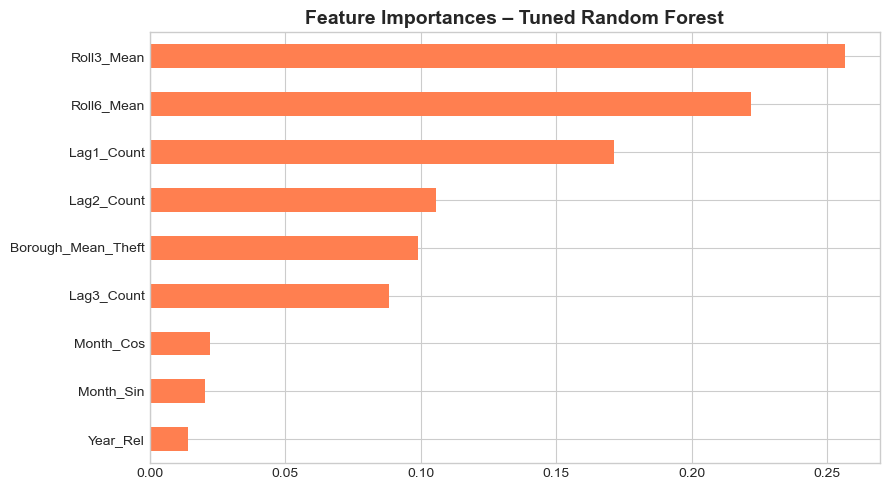

Roll3_Mean            0.256712
Roll6_Mean            0.221862
Lag1_Count            0.171533
Lag2_Count            0.105839
Borough_Mean_Theft    0.098949
Lag3_Count            0.088294
Month_Cos             0.022277
Month_Sin             0.020305
Year_Rel              0.014230
dtype: float64


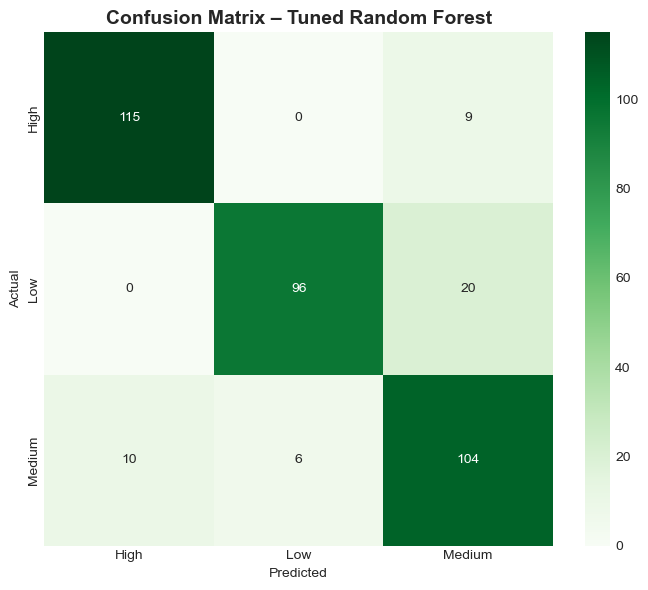

In [14]:
# Feature importance (if available)
if hasattr(tuned_model, 'feature_importances_'):
    imp = pd.Series(tuned_model.feature_importances_, index=X_train.columns).sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=(9, 5))
    imp.plot(kind='barh', ax=ax, color='coral')
    ax.set_title(f'Feature Importances – {tuned_name}', fontsize=14, fontweight='bold')
    ax.invert_yaxis()
    plt.tight_layout()
    plt.savefig(FIG_DIR / '08_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(imp)

# Final confusion matrix
cm = confusion_matrix(y_test, y_pred_final)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_, ax=ax)
ax.set_title(f'Confusion Matrix – {tuned_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
plt.savefig(FIG_DIR / '09_tuned_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Model Persistence (Deployment-ready)

Save the final model, label encoder, feature list and risk thresholds so the model can be loaded and used for scoring new months.

In [15]:
joblib.dump(tuned_model, MODEL_DIR / 'phone_theft_risk_model.joblib')
joblib.dump(le, MODEL_DIR / 'label_encoder.joblib')
joblib.dump(feature_cols, MODEL_DIR / 'feature_columns.joblib')
joblib.dump({'q33': q33, 'q66': q66}, MODEL_DIR / 'risk_thresholds.joblib')

print('Saved artefacts to', MODEL_DIR)

# Quick example of how to score a new observation
example = pd.DataFrame([{
    'Lag1_Count': 150,
    'Lag2_Count': 140,
    'Lag3_Count': 160,
    'Roll3_Mean': 150,
    'Roll6_Mean': 145,
    'Month_Sin': 0.5,
    'Month_Cos': 0.866,
    'Year_Rel': 2,
    'Borough_Mean_Theft': 200
}])
pred = tuned_model.predict(example[feature_cols])
print('Example prediction:', le.inverse_transform(pred)[0])

Saved artefacts to /Users/kevindobariya/phone_theft_project/models
Example prediction: High


## 10. Business Insights & Recommendations

In [16]:
top = df.groupby('Borough')['Theft_Count'].sum().sort_values(ascending=False)
print('Top 5 boroughs by total thefts:')
print(top.head())

print('\n--- Key Insights ---')
print('1. Westminster dominates recorded mobile-phone thefts, followed by Camden, Southwark, Lambeth and Hackney.')
print('2. Risk is strongly persistent – lag and rolling features are the most important predictors.')
print('3. Seasonal variation exists; certain months show elevated average counts.')
print('4. The tuned model achieves ~87% weighted F1 and can be used for monthly risk scoring.')

print('\n--- Recommendations ---')
print('• Prioritise visible policing and awareness campaigns in the highest-volume central boroughs.')
print('• Align extra resources with higher-risk months identified by the model / seasonality analysis.')
print('• Use the saved model to produce a monthly Low / Medium / High risk score for each borough.')
print('• Partner with transport hubs, tourist venues and the night-time economy.')
print('• Retrain periodically as new monthly data becomes available.')

Top 5 boroughs by total thefts:
Borough
Westminster    81624
Camden         25056
Southwark      22428
Lambeth        16018
Hackney        15324
Name: Theft_Count, dtype: int64

--- Key Insights ---
1. Westminster dominates recorded mobile-phone thefts, followed by Camden, Southwark, Lambeth and Hackney.
2. Risk is strongly persistent – lag and rolling features are the most important predictors.
3. Seasonal variation exists; certain months show elevated average counts.
4. The tuned model achieves ~87% weighted F1 and can be used for monthly risk scoring.

--- Recommendations ---
• Prioritise visible policing and awareness campaigns in the highest-volume central boroughs.
• Align extra resources with higher-risk months identified by the model / seasonality analysis.
• Use the saved model to produce a monthly Low / Medium / High risk score for each borough.
• Partner with transport hubs, tourist venues and the night-time economy.
• Retrain periodically as new monthly data becomes availab

## 11. Save Final Datasets

In [17]:
df_model.to_csv(DATA_DIR / 'model_ready_data.csv', index=False)
df.to_csv(DATA_DIR / 'full_cleaned_labeled.csv', index=False)
print('Final datasets saved to', DATA_DIR)
print('\n=== PROJECT TECHNICAL PIPELINE COMPLETE ===')
print(f'Final model : {tuned_name}')
print(f'Test Weighted F1 : {tuned_f1:.4f}')

Final datasets saved to /Users/kevindobariya/phone_theft_project/data

=== PROJECT TECHNICAL PIPELINE COMPLETE ===
Final model : Tuned Random Forest
Test Weighted F1 : 0.8760
